# Linear Algebra for Quantitative Finance

Linear algebra is the language of portfolio theory, factor models, PCA, and correlated simulation. This notebook builds from the ground up — vectors and matrices — through to the spectral decomposition of a covariance matrix and its direct applications.

**Roadmap**

1. Vectors and geometric intuition
2. Matrices — operations, rank, invertibility
3. Systems of linear equations
4. Special matrix structures (symmetric, orthogonal, positive definite)
5. Covariance matrices
6. Eigenvalues and eigenvectors
7. Spectral decomposition and PCA
8. Cholesky decomposition and correlated simulation
9. Finance synthesis: portfolio optimisation geometry

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import numpy.linalg as la

rng = np.random.default_rng(42)

plt.rcParams.update(
    {
        "figure.figsize": (10, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
    }
)

np.set_printoptions(precision=4, suppress=True)

---
## 1  Vectors

A vector $\mathbf{v} \in \mathbb{R}^n$ is an ordered list of $n$ real numbers. In finance, vectors represent:
- A portfolio's **weight vector** $\mathbf{w} = [w_1, \ldots, w_n]^\top$ ($\sum w_i = 1$)
- An asset's **return history** over $T$ periods
- A **factor exposure** (loadings vector)

### 1.1  Norms — measuring size

$$\|\mathbf{v}\|_2 = \sqrt{\sum_i v_i^2} \qquad \|\mathbf{v}\|_1 = \sum_i |v_i| \qquad \|\mathbf{v}\|_\infty = \max_i |v_i|$$

The $L_1$ norm appears in LASSO regularisation; the $L_2$ norm in ridge and Euclidean distance.

### 1.2  Dot product and the angle between vectors

$$\mathbf{u} \cdot \mathbf{v} = \sum_i u_i v_i = \|\mathbf{u}\|_2 \|\mathbf{v}\|_2 \cos\theta$$

- $\mathbf{u} \cdot \mathbf{v} = 0$ $\Leftrightarrow$ **orthogonal** ($\theta = 90°$) — uncorrelated factors in PCA are orthogonal.
- Cosine similarity $\cos\theta = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{u}\|\|\mathbf{v}\|}$ — normalised correlation analogue.

### 1.3  Projection

The projection of $\mathbf{u}$ onto $\mathbf{v}$:

$$\text{proj}_{\mathbf{v}}(\mathbf{u}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\|\mathbf{v}\|^2}\, \mathbf{v}$$

Regression is a projection of the response vector onto the column space of the design matrix.

In [2]:
# Portfolio weight vector — dot product gives portfolio return
w = np.array([0.40, 0.35, 0.25])  # weights: 40% equity, 35% bonds, 25% alternatives
r = np.array([0.12, 0.04, 0.07])  # expected annual returns

port_return = w @ r  # dot product
print(f"Portfolio expected return: {port_return:.2%}")
print(f"Weights sum to: {w.sum():.2f}")
print()

# Norms
print(f"L2 norm of w: {la.norm(w, 2):.4f}")
print(f"L1 norm of w: {la.norm(w, 1):.4f}  (= 1 for long-only)")
print(f"L∞ norm of w: {la.norm(w, np.inf):.4f}  (largest position size)")

Portfolio expected return: 7.95%
Weights sum to: 1.00

L2 norm of w: 0.5874
L1 norm of w: 1.0000  (= 1 for long-only)
L∞ norm of w: 0.4000  (largest position size)


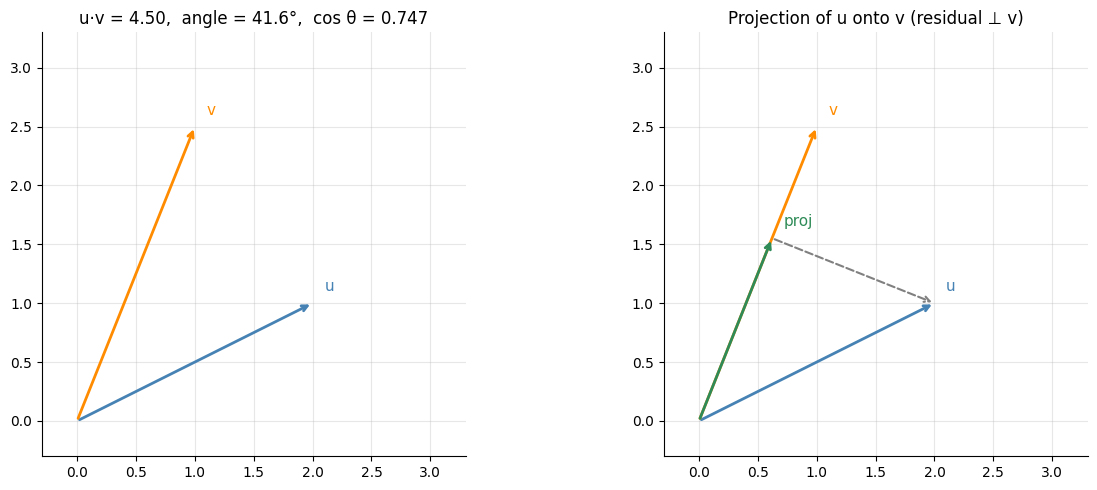

Projection of u onto v: [0.6207 1.5517]
Residual (u - proj):    [ 1.3793 -0.5517]
Check orthogonality:    residual · v = 0.00e+00  (≈ 0)


In [3]:
# Visualise vectors, dot product, and projection in 2D
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

u = np.array([2.0, 1.0])
v = np.array([1.0, 2.5])


def draw_vector(ax, origin, vec, color, label):
    ax.annotate(
        "", xy=origin + vec, xytext=origin, arrowprops=dict(arrowstyle="->", color=color, lw=2)
    )
    ax.text(*(origin + vec + 0.1), label, color=color, fontsize=11)


origin = np.zeros(2)
draw_vector(axes[0], origin, u, "steelblue", "u")
draw_vector(axes[0], origin, v, "darkorange", "v")

cos_theta = u @ v / (la.norm(u) * la.norm(v))
theta_deg = math.degrees(math.acos(cos_theta))
axes[0].set_xlim(-0.3, 3.3)
axes[0].set_ylim(-0.3, 3.3)
axes[0].set_aspect("equal")
axes[0].set_title(f"u·v = {u @ v:.2f},  angle = {theta_deg:.1f}°,  cos θ = {cos_theta:.3f}")

# Projection of u onto v
proj_scalar = (u @ v) / (v @ v)
proj_vec = proj_scalar * v
residual = u - proj_vec

draw_vector(axes[1], origin, u, "steelblue", "u")
draw_vector(axes[1], origin, v, "darkorange", "v")
draw_vector(axes[1], origin, proj_vec, "seagreen", "proj")
# Residual (perpendicular component)
axes[1].annotate(
    "",
    xy=u,
    xytext=proj_vec,
    arrowprops=dict(arrowstyle="->", color="grey", lw=1.5, linestyle="dashed"),
)
axes[1].set_xlim(-0.3, 3.3)
axes[1].set_ylim(-0.3, 3.3)
axes[1].set_aspect("equal")
axes[1].set_title("Projection of u onto v (residual ⊥ v)")

plt.tight_layout()
plt.show()

print(f"Projection of u onto v: {proj_vec}")
print(f"Residual (u - proj):    {residual}")
print(f"Check orthogonality:    residual · v = {residual @ v:.2e}  (≈ 0)")

---
## 2  Matrices — Operations, Rank, Invertibility

A matrix $A \in \mathbb{R}^{m \times n}$ is a linear map from $\mathbb{R}^n$ to $\mathbb{R}^m$. Every matrix multiplication $A\mathbf{x}$ transforms an input vector.

### 2.1  Key operations

| Operation | Notation | Finance use |
|---|---|---|
| Transpose | $A^\top$, $(A^\top)_{ij} = A_{ji}$ | Switching between row/col conventions |
| Matrix multiply | $(AB)_{ij} = \sum_k A_{ik} B_{kj}$ | Portfolio variance: $\mathbf{w}^\top \Sigma \mathbf{w}$ |
| Inverse | $A^{-1}$, requires square and full rank | Solving linear systems, OLS: $(X^\top X)^{-1}$ |
| Trace | $\text{tr}(A) = \sum_i A_{ii}$ | Sum of eigenvalues = total variance |
| Determinant | $\det(A)$ | Volume scaling factor; $\det(\Sigma)$ = generalised variance |

### 2.2  Rank

The **rank** of $A$ is the dimension of its column space (= row space). A matrix with $\text{rank}(A) < \min(m,n)$ is **rank-deficient** — it cannot be inverted and maps some non-zero vectors to zero.

A covariance matrix built from $T$ observations on $n$ assets is rank-deficient when $T < n$ — a common problem in large portfolio construction.

### 2.3  Matrix norms

$$\|A\|_F = \sqrt{\sum_{i,j} A_{ij}^2} \quad \text{(Frobenius)} \qquad \|A\|_2 = \sigma_{\max}(A) \quad \text{(spectral)}$$

In [4]:
# Matrix operations: portfolio variance formula
# σ²_p = w^T Σ w
n = 3
# Construct a valid covariance matrix from correlation + individual vols
vols = np.array([0.20, 0.10, 0.15])  # annual vols
corr = np.array(
    [
        [1.00, 0.60, -0.10],
        [0.60, 1.00, 0.20],
        [-0.10, 0.20, 1.00],
    ]
)
D = np.diag(vols)  # diagonal vol matrix
Sigma = D @ corr @ D  # Σ = D·C·D

w = np.array([0.40, 0.35, 0.25])
port_var = w @ Sigma @ w
port_vol = math.sqrt(port_var)

print("Covariance matrix Σ:")
print(Sigma)
print(f"\nPortfolio variance:   w^T Σ w = {port_var:.6f}")
print(f"Portfolio volatility:          = {port_vol:.2%}")
print(f"Weighted avg vol (no corr):    = {(w @ vols):.2%}  ← diversification reduces this")
print(f"\ndet(Σ) = {la.det(Sigma):.6f}  (generalised variance)")
print(f"tr(Σ)  = {np.trace(Sigma):.6f}  (= sum of individual variances)")
print(f"rank   = {la.matrix_rank(Sigma)}  (full rank = {n})")

Covariance matrix Σ:
[[ 0.04    0.012  -0.003 ]
 [ 0.012   0.01    0.003 ]
 [-0.003   0.003   0.0225]]

Portfolio variance:   w^T Σ w = 0.012316
Portfolio volatility:          = 11.10%
Weighted avg vol (no corr):    = 15.25%  ← diversification reduces this

det(Σ) = 0.000005  (generalised variance)
tr(Σ)  = 0.072500  (= sum of individual variances)
rank   = 3  (full rank = 3)


In [5]:
# Rank deficiency: T < n observations → covariance matrix loses rank
n_assets = 10
T_obs = 8  # fewer observations than assets

X = rng.standard_normal((T_obs, n_assets))  # T×n return matrix
Sigma_deficient = X.T @ X / (T_obs - 1)

print(f"n_assets = {n_assets}, T_obs = {T_obs}")
print(f"Rank of sample covariance matrix: {la.matrix_rank(Sigma_deficient)} (not invertible)")
print(f"Smallest eigenvalue: {la.eigvalsh(Sigma_deficient).min():.4e}  (≈ 0 → rank-deficient)")
print()
print("Fix: use T >> n, shrinkage estimator, or factor model to regularise.")

n_assets = 10, T_obs = 8
Rank of sample covariance matrix: 8 (not invertible)
Smallest eigenvalue: -1.9930e-16  (≈ 0 → rank-deficient)

Fix: use T >> n, shrinkage estimator, or factor model to regularise.


---
## 3  Systems of Linear Equations

$$A\mathbf{x} = \mathbf{b}$$

- **Unique solution** when $A$ is square and invertible: $\mathbf{x} = A^{-1}\mathbf{b}$ (use `np.linalg.solve`, not explicit inverse — faster, more numerically stable).
- **Least squares** (overdetermined, $m > n$): minimise $\|A\mathbf{x} - \mathbf{b}\|_2^2$ → $\hat{\mathbf{x}} = (A^\top A)^{-1} A^\top \mathbf{b}$ (OLS normal equations).
- **Underdetermined** ($m < n$): infinitely many solutions — minimum-norm solution via pseudoinverse.

The **Moore-Penrose pseudoinverse** $A^+$ handles all three cases uniformly.

In [6]:
# OLS as a linear system: regress asset returns on a market factor
T = 500
true_alpha = 0.0002  # daily alpha
true_beta = 1.25  # market beta

market_return = rng.normal(0.0004, 0.012, size=T)
idio_noise = rng.normal(0.0, 0.008, size=T)
asset_return = true_alpha + true_beta * market_return + idio_noise

# Design matrix: intercept + market factor
X = np.column_stack([np.ones(T), market_return])  # T×2
y = asset_return

# OLS via normal equations: β̂ = (X^T X)^{-1} X^T y
beta_hat = la.solve(X.T @ X, X.T @ y)

# Or equivalently via least-squares solver (more numerically stable)
beta_lstsq, *_ = la.lstsq(X, y, rcond=None)

print("OLS regression: asset_return = α + β·market_return + ε")
print(f"  True  α = {true_alpha:.4f}   β = {true_beta:.4f}")
print(f"  OLS   α̂ = {beta_hat[0]:.4f}   β̂ = {beta_hat[1]:.4f}  (normal equations)")
print(f"  OLS   α̂ = {beta_lstsq[0]:.4f}   β̂ = {beta_lstsq[1]:.4f}  (lstsq)")

residuals = y - X @ beta_hat
r_squared = 1 - residuals.var() / y.var()
print(f"  R²  = {r_squared:.4f}")

OLS regression: asset_return = α + β·market_return + ε
  True  α = 0.0002   β = 1.2500
  OLS   α̂ = -0.0001   β̂ = 1.2415  (normal equations)
  OLS   α̂ = -0.0001   β̂ = 1.2415  (lstsq)
  R²  = 0.7691


---
## 4  Special Matrix Structures

### 4.1  Symmetric matrices

$A = A^\top$. Covariance matrices and correlation matrices are always symmetric. Key property: **all eigenvalues are real**.

### 4.2  Orthogonal matrices

$Q^\top Q = Q Q^\top = I$, so $Q^{-1} = Q^\top$. Columns are orthonormal: $\|q_i\|=1$ and $q_i \cdot q_j = 0$ for $i \ne j$.

Orthogonal matrices preserve norms and angles — they are pure **rotations** (and reflections). PCA eigenvectors form an orthogonal matrix.

### 4.3  Positive (Semi-)Definite matrices

$A$ is **positive definite** (PD) if $\mathbf{x}^\top A \mathbf{x} > 0$ for all $\mathbf{x} \ne \mathbf{0}$. Equivalently, all eigenvalues $> 0$.

$A$ is **positive semi-definite** (PSD) if $\mathbf{x}^\top A \mathbf{x} \ge 0$ (eigenvalues $\ge 0$).

Every valid covariance matrix is PSD. Portfolio variance $\sigma_p^2 = \mathbf{w}^\top \Sigma \mathbf{w} \ge 0$ requires this.

In [7]:
# Check PSD: valid covariance matrix vs a broken one
Sigma_valid = np.array(
    [
        [0.04, 0.012, -0.003],
        [0.012, 0.01, 0.003],
        [-0.003, 0.003, 0.0225],
    ]
)

Sigma_broken = np.array(
    [
        [0.04, 0.10, 0.0],  # off-diagonal > product of diagonals → not PSD
        [0.10, 0.01, 0.0],
        [0.0, 0.0, 0.02],
    ]
)

for name, M in [("Valid Σ", Sigma_valid), ("Broken Σ", Sigma_broken)]:
    eigvals = la.eigvalsh(M)  # eigvalsh exploits symmetry, returns sorted real eigenvalues
    is_psd = np.all(eigvals >= -1e-10)
    print(f"{name}: eigenvalues = {eigvals}  →  {'PSD ✓' if is_psd else 'NOT PSD ✗'}")

print()

# Neat construction: any A → A^T A is always PSD
A = rng.standard_normal((5, 3))
M = A.T @ A
print(f"A^T A eigenvalues: {la.eigvalsh(M).round(4)}  (always ≥ 0)")

Valid Σ: eigenvalues = [0.005  0.0232 0.0444]  →  PSD ✓
Broken Σ: eigenvalues = [-0.0761  0.02    0.1261]  →  NOT PSD ✗

A^T A eigenvalues: [0.2899 0.5334 5.9199]  (always ≥ 0)


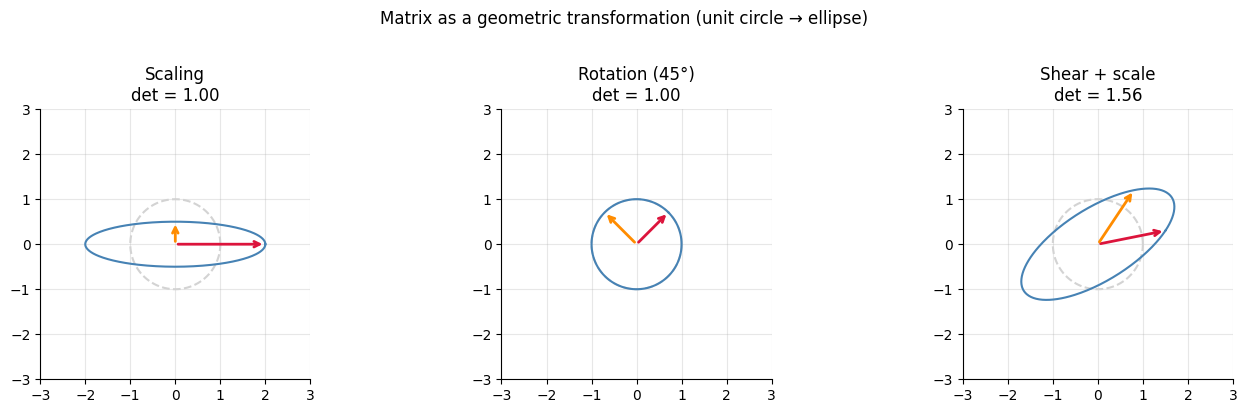

In [8]:
# Geometric view: how a matrix transforms the unit circle
theta = np.linspace(0, 2 * math.pi, 300)
circle = np.array([np.cos(theta), np.sin(theta)])  # 2×300

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

transforms = [
    ("Scaling", np.array([[2.0, 0.0], [0.0, 0.5]])),
    (
        "Rotation (45°)",
        np.array(
            [
                [math.cos(math.pi / 4), -math.sin(math.pi / 4)],
                [math.sin(math.pi / 4), math.cos(math.pi / 4)],
            ]
        ),
    ),
    ("Shear + scale", np.array([[1.5, 0.8], [0.3, 1.2]])),
]

for ax, (label, M) in zip(axes, transforms):
    transformed = M @ circle
    ax.plot(circle[0], circle[1], "--", color="lightgrey", label="Unit circle")
    ax.plot(transformed[0], transformed[1], color="steelblue", label="Transformed")
    # Draw basis vectors before and after
    for e, col in [(np.array([1, 0]), "crimson"), (np.array([0, 1]), "darkorange")]:
        ax.annotate("", xy=M @ e, xytext=[0, 0], arrowprops=dict(arrowstyle="->", color=col, lw=2))
    ax.set_aspect("equal")
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_title(f"{label}\ndet = {la.det(M):.2f}")

plt.suptitle("Matrix as a geometric transformation (unit circle → ellipse)", y=1.02)
plt.tight_layout()
plt.show()

---
## 5  Covariance Matrices in Detail

Given $T$ observations of $n$ assets, with demeaned return matrix $\tilde{R} \in \mathbb{R}^{T \times n}$:

$$\hat{\Sigma} = \frac{1}{T-1} \tilde{R}^\top \tilde{R}$$

This is the **sample covariance matrix** — always PSD, PD when $T > n$.

### 5.1  Structure: the decomposition $\Sigma = D\,C\,D$

$$\Sigma_{ij} = \sigma_i \cdot \rho_{ij} \cdot \sigma_j$$

where $D = \text{diag}(\sigma_1, \ldots, \sigma_n)$ and $C$ is the correlation matrix. This separates **volatility** from **correlation** — useful for stress testing (e.g., shock correlations independently of vols).

### 5.2  Shrinkage estimators

The sample covariance is noisy for large $n$ or small $T$. **Ledoit-Wolf shrinkage** blends it toward a structured target:

$$\hat{\Sigma}_{LW} = (1-\alpha)\hat{\Sigma} + \alpha \cdot \text{Target}$$

Common targets: scaled identity (Ledoit-Wolf), constant correlation, factor model structure.

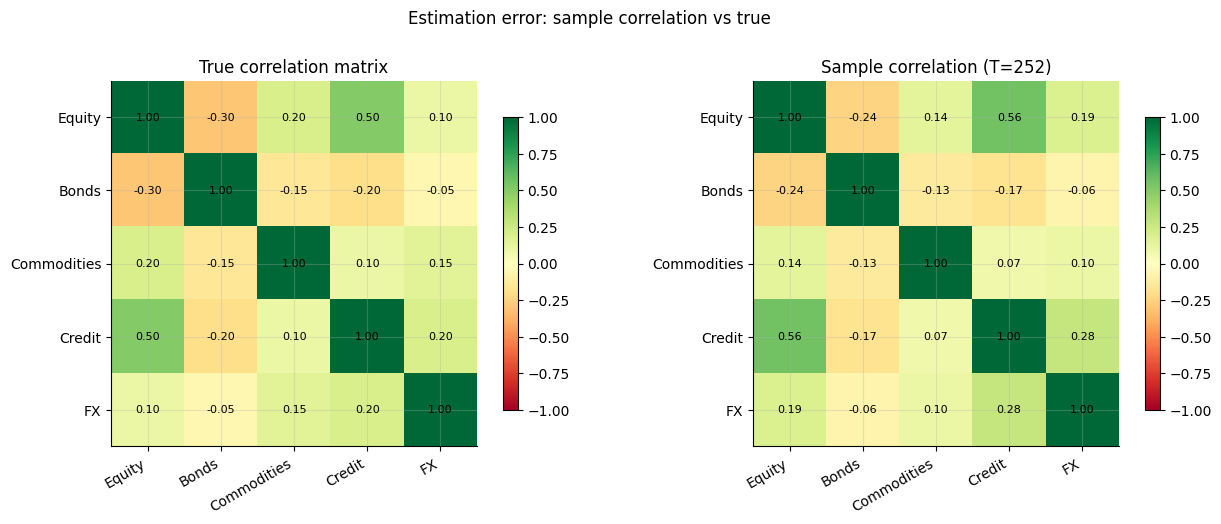


Frobenius error in correlation: 0.2404


In [9]:
# Build and inspect a sample covariance matrix
n_assets = 5
asset_names = ["Equity", "Bonds", "Commodities", "Credit", "FX"]
T = 252  # one year of daily returns

# True parameters
true_vols = np.array([0.18, 0.06, 0.22, 0.12, 0.10])
true_corr = np.array(
    [
        [1.00, -0.30, 0.20, 0.50, 0.10],
        [-0.30, 1.00, -0.15, -0.20, -0.05],
        [0.20, -0.15, 1.00, 0.10, 0.15],
        [0.50, -0.20, 0.10, 1.00, 0.20],
        [0.10, -0.05, 0.15, 0.20, 1.00],
    ]
)
true_cov = np.diag(true_vols) @ true_corr @ np.diag(true_vols)

# Simulate returns from the true distribution
L = la.cholesky(true_cov)  # we'll explain this in section 8
Z = rng.standard_normal((T, n_assets))
returns = Z @ L.T  # shape T×n

# Sample covariance
sample_cov = np.cov(returns, rowvar=False)  # rowvar=False: rows=obs, cols=assets

# Recover correlation matrix and vols from sample covariance
sample_vols = np.sqrt(np.diag(sample_cov))
D_inv = np.diag(1.0 / sample_vols)
sample_corr = D_inv @ sample_cov @ D_inv

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mat, title in [
    (axes[0], true_corr, "True correlation matrix"),
    (axes[1], sample_corr, f"Sample correlation (T={T})"),
]:
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdYlGn")
    ax.set_xticks(range(n_assets))
    ax.set_yticks(range(n_assets))
    ax.set_xticklabels(asset_names, rotation=30, ha="right")
    ax.set_yticklabels(asset_names)
    for i in range(n_assets):
        for j in range(n_assets):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle("Estimation error: sample correlation vs true", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nFrobenius error in correlation: {la.norm(sample_corr - true_corr, 'fro'):.4f}")

---
## 6  Eigenvalues and Eigenvectors

For a square matrix $A$, the **eigenvalue equation** is:

$$A\mathbf{v} = \lambda \mathbf{v}$$

$\mathbf{v} \ne \mathbf{0}$ is an **eigenvector** and $\lambda$ is its **eigenvalue**. The matrix $A$ merely scales $\mathbf{v}$ — it does not rotate it.

For a symmetric matrix $A$ (Spectral Theorem):
- All eigenvalues $\lambda_i$ are **real**
- Eigenvectors for distinct eigenvalues are **orthogonal**
- $A$ can be diagonalised: $A = Q \Lambda Q^\top$ where $Q$ is orthogonal and $\Lambda = \text{diag}(\lambda_1, \ldots, \lambda_n)$

### Finance interpretation for $\Sigma$

| Quantity | Interpretation |
|---|---|
| Eigenvector $\mathbf{q}_1$ | Portfolio with maximum variance (first principal component) |
| $\lambda_1$ | Variance explained by that portfolio |
| $\sum_i \lambda_i = \text{tr}(\Sigma)$ | Total variance across all assets |
| $\lambda_i / \sum \lambda_j$ | Fraction of total variance explained by PC $i$ |

In [10]:
# Eigendecomposition of the covariance matrix
eigvals, eigvecs = la.eigh(true_cov)  # eigh: for symmetric/Hermitian; sorted ascending
eigvals = eigvals[::-1]  # flip to descending order
eigvecs = eigvecs[:, ::-1]

total_var = eigvals.sum()
pct_explained = eigvals / total_var * 100
cumulative = np.cumsum(pct_explained)

print("Eigenvalues of Σ (= variance of each principal portfolio):")
print(f"{'PC':>4}  {'Eigenvalue':>12}  {'Var explained':>14}  {'Cumulative':>11}")
print("-" * 46)
for i, (lam, pct, cum) in enumerate(zip(eigvals, pct_explained, cumulative)):
    print(f"  {i + 1:2d}  {lam:12.6f}  {pct:13.2f}%  {cum:10.2f}%")

print(f"\ntr(Σ) = {np.trace(true_cov):.6f}  =  Σλᵢ = {total_var:.6f}")
print(f"det(Σ) = {la.det(true_cov):.6e}  =  Πλᵢ = {np.prod(eigvals):.6e}")

Eigenvalues of Σ (= variance of each principal portfolio):
  PC    Eigenvalue   Var explained   Cumulative
----------------------------------------------
   1      0.053514          49.19%       49.19%
   2      0.033187          30.50%       79.69%
   3      0.010923          10.04%       89.73%
   4      0.007973           7.33%       97.06%
   5      0.003204           2.94%      100.00%

tr(Σ) = 0.108800  =  Σλᵢ = 0.108800
det(Σ) = 4.954569e-10  =  Πλᵢ = 4.954569e-10


In [11]:
# Reconstruct Σ from eigendecomposition: Σ = Q Λ Q^T
Lambda = np.diag(eigvals)
Q = eigvecs

Sigma_reconstructed = Q @ Lambda @ Q.T
print(f"Reconstruction error: {la.norm(Sigma_reconstructed - true_cov):.2e}  (machine precision)")

# Q is orthogonal: Q^T Q = I
print(f"Orthogonality check:  max|Q^T Q - I| = {la.norm(Q.T @ Q - np.eye(n_assets), np.inf):.2e}")

Reconstruction error: 3.19e-17  (machine precision)
Orthogonality check:  max|Q^T Q - I| = 8.69e-16


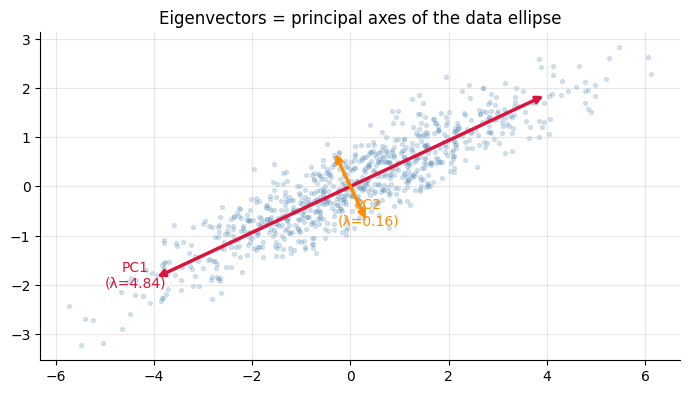

In [12]:
# Visualise: 2D example — eigenvectors as principal axes of the data ellipse
cov_2d = np.array([[4.0, 1.8], [1.8, 1.0]])
eigvals_2d, eigvecs_2d = la.eigh(cov_2d)
eigvals_2d = eigvals_2d[::-1]
eigvecs_2d = eigvecs_2d[:, ::-1]

# Sample from this 2D Gaussian
L_2d = la.cholesky(cov_2d)
samples_2d = rng.standard_normal((800, 2)) @ L_2d.T

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(samples_2d[:, 0], samples_2d[:, 1], alpha=0.2, s=8, color="steelblue")

# Draw eigenvectors scaled by sqrt(eigenvalue) (= std in that direction)
colors = ["crimson", "darkorange"]
for i in range(2):
    scale = math.sqrt(eigvals_2d[i])
    ev = eigvecs_2d[:, i] * scale * 2  # scale for visibility
    ax.annotate("", xy=ev, xytext=-ev, arrowprops=dict(arrowstyle="<->", color=colors[i], lw=2.5))
    ax.text(
        *(ev * 1.1),
        f"PC{i + 1}\n(λ={eigvals_2d[i]:.2f})",
        color=colors[i],
        ha="center",
        fontsize=10,
    )

ax.set_aspect("equal")
ax.set_title("Eigenvectors = principal axes of the data ellipse")
plt.tight_layout()
plt.show()

---
## 7  Spectral Decomposition and PCA

**Principal Component Analysis (PCA)** rotates the data into a new coordinate system where:
- Axes are the eigenvectors of the covariance matrix $\Sigma$ (= principal components)
- Variance along each axis equals the corresponding eigenvalue
- Components are orthogonal (uncorrelated)

**Algorithm:**
1. Demean the return matrix: $\tilde{R} = R - \bar{R}$
2. Compute the sample covariance $\hat{\Sigma}$
3. Eigendecompose: $\hat{\Sigma} = Q\Lambda Q^\top$
4. Project: $Z = \tilde{R} Q$ — factor scores (PC time series)
5. Retain the top $k$ PCs that explain a target variance fraction

**Finance uses:**
- **Factor extraction**: PC1 often ≈ market factor, PC2 ≈ value/growth, etc.
- **Dimensionality reduction**: compress 500 stocks into 5–10 factors
- **Risk decomposition**: how much variance does each factor explain?
- **Covariance regularisation**: reconstruct $\Sigma$ from top-$k$ PCs only (factor model)

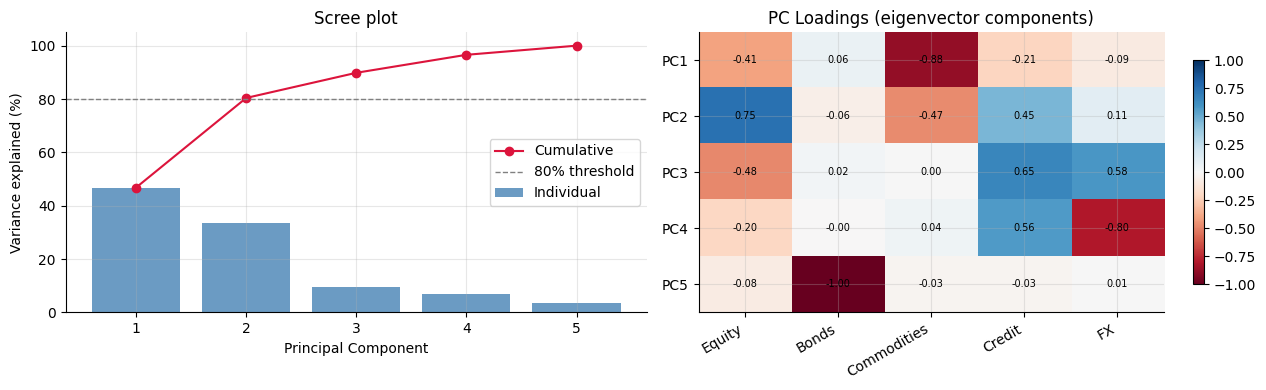

In [13]:
# PCA on the simulated return data
R_demeaned = returns - returns.mean(axis=0)
Sigma_hat = R_demeaned.T @ R_demeaned / (T - 1)

eigvals_s, eigvecs_s = la.eigh(Sigma_hat)
eigvals_s = eigvals_s[::-1]
eigvecs_s = eigvecs_s[:, ::-1]

# PC scores (factor time series)
Z = R_demeaned @ eigvecs_s  # T × n

# Scree plot
pct_exp = eigvals_s / eigvals_s.sum() * 100
cumul_exp = np.cumsum(pct_exp)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, n_assets + 1), pct_exp, color="steelblue", alpha=0.8, label="Individual")
axes[0].plot(range(1, n_assets + 1), cumul_exp, "o-", color="crimson", label="Cumulative")
axes[0].axhline(80, color="grey", linestyle="--", linewidth=1, label="80% threshold")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance explained (%)")
axes[0].set_title("Scree plot")
axes[0].legend()

# PC loadings heatmap
im = axes[1].imshow(eigvecs_s.T, cmap="RdBu", vmin=-1, vmax=1, aspect="auto")
axes[1].set_xticks(range(n_assets))
axes[1].set_xticklabels(asset_names, rotation=30, ha="right")
axes[1].set_yticks(range(n_assets))
axes[1].set_yticklabels([f"PC{i + 1}" for i in range(n_assets)])
for i in range(n_assets):
    for j in range(n_assets):
        axes[1].text(j, i, f"{eigvecs_s[j, i]:.2f}", ha="center", va="center", fontsize=7)
axes[1].set_title("PC Loadings (eigenvector components)")
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

In [14]:
# Low-rank approximation: reconstruct Σ using only top-k PCs
# This is the core of a factor-model covariance estimator


def low_rank_cov(eigvals: np.ndarray, eigvecs: np.ndarray, k: int) -> np.ndarray:
    """Reconstruct covariance from top-k principal components."""
    Qk = eigvecs[:, :k]
    Lk = np.diag(eigvals[:k])
    return Qk @ Lk @ Qk.T


print("Frobenius error vs full sample covariance (reconstruction with k PCs):")
for k in range(1, n_assets + 1):
    Sigma_k = low_rank_cov(eigvals_s, eigvecs_s, k)
    err = la.norm(Sigma_k - Sigma_hat, "fro")
    var_captured = eigvals_s[:k].sum() / eigvals_s.sum()
    print(f"  k={k}: error = {err:.6f}   variance captured = {var_captured:.1%}")

print("\nk=n perfectly reconstructs the full matrix (eigenvectors form a basis).")

Frobenius error vs full sample covariance (reconstruction with k PCs):
  k=1: error = 0.039707   variance captured = 46.8%
  k=2: error = 0.013444   variance captured = 80.4%
  k=3: error = 0.008413   variance captured = 89.8%
  k=4: error = 0.003810   variance captured = 96.6%
  k=5: error = 0.000000   variance captured = 100.0%

k=n perfectly reconstructs the full matrix (eigenvectors form a basis).


---
## 8  Cholesky Decomposition and Correlated Simulation

For a PD matrix $\Sigma$, the **Cholesky decomposition** gives a unique lower-triangular $L$ such that:

$$\Sigma = L L^\top$$

It is the matrix analogue of taking a square root. This is the standard tool for **simulating correlated returns**:

1. Draw $Z \sim \mathcal{N}(\mathbf{0}, I_n)$ — independent standard normals
2. Transform: $X = \mu + L Z$ so $\text{Cov}(X) = L\,I\,L^\top = LL^\top = \Sigma$

**Why Cholesky over eigendecomposition for simulation?**
- $O(n^3/3)$ vs $O(n^3)$ — roughly 2–3× faster
- Numerically stable for PD matrices
- The eigendecomposition is preferred when $\Sigma$ is only PSD (near-singular), where you zero out negative eigenvalues

In [15]:
# Cholesky decomposition
print("Cholesky factor L  (L L^T = Σ):")
print(L)  # computed earlier
print()
print(f"Reconstruction error: {la.norm(L @ L.T - true_cov):.2e}")
print(f"L is lower-triangular: {np.allclose(L, np.tril(L))}")

Cholesky factor L  (L L^T = Σ):
[[ 0.18    0.      0.      0.      0.    ]
 [-0.018   0.0572  0.      0.      0.    ]
 [ 0.044  -0.0208  0.2146  0.      0.    ]
 [ 0.06   -0.0063 -0.0006  0.1037  0.    ]
 [ 0.01   -0.0021  0.0131  0.0173  0.0971]]

Reconstruction error: 3.10e-18
L is lower-triangular: True


In [16]:
# Correlated simulation: verify the output matches the target covariance
n_scenarios = 100_000
mu_daily = np.zeros(n_assets)  # zero mean for simplicity

Z = rng.standard_normal((n_scenarios, n_assets))
X = Z @ L.T  # shape: n_scenarios × n_assets

empirical_cov = np.cov(X, rowvar=False)
empirical_corr = np.corrcoef(X, rowvar=False)

print(f"Simulated {n_scenarios:,} scenarios")
print(f"\nTarget vols:    {np.sqrt(np.diag(true_cov))}")
print(f"Empirical vols: {np.sqrt(np.diag(empirical_cov)).round(4)}")
print(f"\nFrobenius error (cov):  {la.norm(empirical_cov - true_cov):.6f}")
print(f"Frobenius error (corr): {la.norm(empirical_corr - true_corr):.6f}")

Simulated 100,000 scenarios

Target vols:    [0.18 0.06 0.22 0.12 0.1 ]
Empirical vols: [0.1801 0.06   0.2203 0.12   0.1002]

Frobenius error (cov):  0.000248
Frobenius error (corr): 0.008834


In [17]:
# Spectral method for near-PSD matrices (handles small negative eigenvalues)
def simulate_correlated_spectral(
    Sigma: np.ndarray,
    n_scenarios: int,
    rng: np.random.Generator,
) -> np.ndarray:
    eigvals_sim, eigvecs_sim = la.eigh(Sigma)
    eigvals_sim = np.maximum(eigvals_sim, 0)  # clip negative eigenvalues
    L_spectral = eigvecs_sim @ np.diag(np.sqrt(eigvals_sim))
    Z = rng.standard_normal((n_scenarios, Sigma.shape[0]))
    return Z @ L_spectral.T


# Both approaches give identical results for PD matrices
X_spectral = simulate_correlated_spectral(true_cov, n_scenarios=10_000, rng=rng)
X_cholesky = rng.standard_normal((10_000, n_assets)) @ L.T

print(
    "Cov estimation error (spectral): ",
    la.norm(np.cov(X_spectral, rowvar=False) - true_cov, "fro").round(6),
)
print(
    "Cov estimation error (Cholesky): ",
    la.norm(np.cov(X_cholesky, rowvar=False) - true_cov, "fro").round(6),
)

Cov estimation error (spectral):  0.000637
Cov estimation error (Cholesky):  0.001172


---
## 9  Finance Synthesis: Portfolio Optimisation Geometry

The mean-variance optimisation problem (Markowitz) is fundamentally a linear-algebraic one.

**Minimum variance portfolio** (unconstrained):

$$\mathbf{w}^* = \frac{\Sigma^{-1} \mathbf{1}}{\mathbf{1}^\top \Sigma^{-1} \mathbf{1}}$$

**Maximum Sharpe ratio portfolio** (unconstrained, given expected return vector $\boldsymbol{\mu}$):

$$\mathbf{w}^* \propto \Sigma^{-1} \boldsymbol{\mu}$$

Both require inverting $\Sigma$ — which is why PD (invertible) covariance matrices matter, and why shrinkage / factor models are used when $\Sigma$ is ill-conditioned.

The **efficient frontier** is the set of minimum-variance portfolios for each target return level. In weight space it is a curve; in (volatility, return) space it is a hyperbola.

In [18]:
# Efficient frontier: analytical solution for the 5-asset universe
mu_ann = np.array([0.10, 0.04, 0.08, 0.06, 0.05])  # expected annual returns

Sigma_inv = la.inv(true_cov)
ones = np.ones(n_assets)

# Minimum variance portfolio
w_mv_unnorm = Sigma_inv @ ones
w_mv = w_unnorm = w_mv_unnorm / (ones @ w_mv_unnorm)
vol_mv = math.sqrt(w_mv @ true_cov @ w_mv)
ret_mv = w_mv @ mu_ann

# Maximum Sharpe (tangency) portfolio (risk-free = 2%)
rf = 0.02
excess_mu = mu_ann - rf
w_tan_unnorm = Sigma_inv @ excess_mu
w_tan = w_tan_unnorm / w_tan_unnorm.sum()
vol_tan = math.sqrt(w_tan @ true_cov @ w_tan)
ret_tan = w_tan @ mu_ann
sharpe_tan = (ret_tan - rf) / vol_tan

print("Minimum Variance Portfolio:")
for name, wi in zip(asset_names, w_mv):
    print(f"  {name:15s}: {wi:+.4f}")
print(f"  → E[r] = {ret_mv:.2%},  σ = {vol_mv:.2%}")

print("\nMaximum Sharpe (Tangency) Portfolio:")
for name, wi in zip(asset_names, w_tan):
    print(f"  {name:15s}: {wi:+.4f}")
print(f"  → E[r] = {ret_tan:.2%},  σ = {vol_tan:.2%},  Sharpe = {sharpe_tan:.2f}")

Minimum Variance Portfolio:
  Equity         : +0.0665
  Bonds          : +0.6387
  Commodities    : +0.0365
  Credit         : +0.1080
  FX             : +0.1503
  → E[r] = 4.91%,  σ = 4.26%

Maximum Sharpe (Tangency) Portfolio:
  Equity         : +0.1636
  Bonds          : +0.5665
  Commodities    : +0.0602
  Credit         : +0.0729
  FX             : +0.1368
  → E[r] = 5.51%,  σ = 4.67%,  Sharpe = 0.75


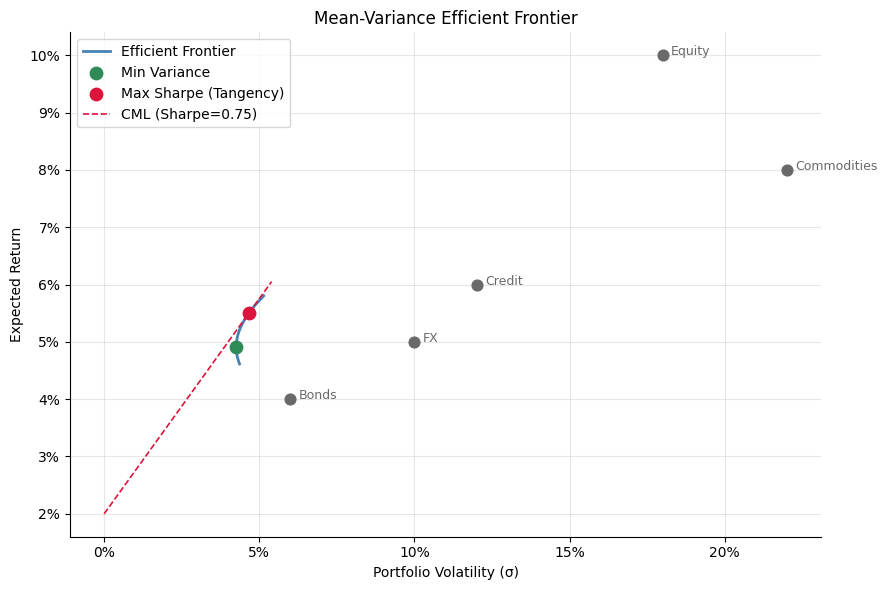

In [19]:
# Trace out the efficient frontier via convex combinations of two frontier portfolios
# (two-fund separation theorem: every frontier portfolio is a mix of any two frontier portfolios)

alphas = np.linspace(-0.5, 1.5, 300)  # allow short-selling
frontier_vols = []
frontier_rets = []

for a in alphas:
    w = a * w_mv + (1 - a) * w_tan
    frontier_vols.append(math.sqrt(w @ true_cov @ w))
    frontier_rets.append(w @ mu_ann)

# Individual assets
asset_vols = np.sqrt(np.diag(true_cov))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(frontier_vols, frontier_rets, color="steelblue", linewidth=2, label="Efficient Frontier")

# Scatter individual assets
ax.scatter(asset_vols, mu_ann, zorder=5, color="dimgrey", s=60)
for i, name in enumerate(asset_names):
    ax.annotate(
        name,
        (asset_vols[i], mu_ann[i]),
        textcoords="offset points",
        xytext=(6, 0),
        fontsize=9,
        color="dimgrey",
    )

# Mark key portfolios
ax.scatter(vol_mv, ret_mv, zorder=6, color="seagreen", s=80, label="Min Variance")
ax.scatter(vol_tan, ret_tan, zorder=6, color="crimson", s=80, label="Max Sharpe (Tangency)")

# Capital Market Line
vol_range = np.linspace(0, max(frontier_vols) * 1.05, 200)
cml = rf + sharpe_tan * vol_range
ax.plot(
    vol_range, cml, "--", color="crimson", linewidth=1.2, label=f"CML (Sharpe={sharpe_tan:.2f})"
)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_xlabel("Portfolio Volatility (σ)")
ax.set_ylabel("Expected Return")
ax.set_title("Mean-Variance Efficient Frontier")
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# Condition number: sensitivity of Σ⁻¹ to estimation error
# High condition number → small errors in Σ lead to large errors in Σ⁻¹ → unstable weights
cond = la.cond(true_cov)
print(f"Condition number of Σ: {cond:.2f}")
print(f"  = λ_max / λ_min = {eigvals.max():.4f} / {eigvals.min():.4f}")
print()

# Ledoit-Wolf-style shrinkage: blend toward scaled identity
alpha_shrink = 0.3
mu_cov = np.trace(true_cov) / n_assets  # target: scaled identity
Sigma_shrunk = (1 - alpha_shrink) * true_cov + alpha_shrink * mu_cov * np.eye(n_assets)

cond_shrunk = la.cond(Sigma_shrunk)
print(f"After shrinkage (α={alpha_shrink}):")
print(f"  Condition number: {cond_shrunk:.2f}  (reduced by {(1 - cond_shrunk / cond) * 100:.1f}%)")
print("  Shrinkage pulls eigenvalues toward their mean, reducing extreme ratios.")

Condition number of Σ: 16.70
  = λ_max / λ_min = 0.0535 / 0.0032

After shrinkage (α=0.3):
  Condition number: 5.02  (reduced by 70.0%)
  Shrinkage pulls eigenvalues toward their mean, reducing extreme ratios.


---
## Summary

| Concept | Core formula | Finance application |
|---|---|---|
| Dot product | $\mathbf{w}^\top \mathbf{r}$ | Portfolio return |
| Quadratic form | $\mathbf{w}^\top \Sigma \mathbf{w}$ | Portfolio variance |
| Rank | $\text{rank}(\Sigma) < n$ | Rank deficiency when $T < n$ |
| OLS | $(X^\top X)^{-1} X^\top y$ | Factor model regression |
| Spectral theorem | $\Sigma = Q\Lambda Q^\top$ | PCA, factor decomposition |
| Eigenvalue $\lambda_i$ | Variance of PC $i$ | Risk attribution |
| Eigenvector $\mathbf{q}_i$ | Loadings of PC $i$ | Factor weights |
| Cholesky | $\Sigma = LL^\top$ | Correlated scenario simulation |
| Condition number | $\lambda_{\max}/\lambda_{\min}$ | Numerical stability of $\Sigma^{-1}$ |
| Min-variance weights | $\Sigma^{-1}\mathbf{1} / (\mathbf{1}^\top\Sigma^{-1}\mathbf{1})$ | Efficient frontier anchor |
| Tangency weights | $\propto \Sigma^{-1}\boldsymbol{\mu}$ | Max Sharpe portfolio |